In [ ]:
import torch

if torch.cuda.is_available():
    print("✅ GPU Available:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU Not Available")


✅ GPU Available: Tesla T4


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aswinsp2004","key":"0b8affd9521569b72466d90152928eb1"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets list


ref                                                       title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset    Screen Time, Sleep & Stress Analysis Dataset         787136  2026-02-13 06:56:18.757000          11942        240  1.0              
amar5693/student-performance-dataset                      Student Performance Dataset                          177286  2026-02-12 06:04:44.613000          10352        165  1.0              
dmahajanbe23/bmw-global-automotive-sales                  BMW Global Automotive Sales                           55017  2026-02-22 18:18:38.170000           2467         51  1.0              
shree0910/online-vs-in-store-shopping-behavio

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip -d pneumonia_data


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  chest-xray-pneumonia.zip
replace pneumonia_data/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset
!unzip tuberculosis-tb-chest-xray-dataset.zip -d tb_data


Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
 84% 560M/663M [00:33<00:06, 16.7MB/s]
100% 663M/663M [00:33<00:00, 20.9MB/s]
Archive:  tuberculosis-tb-chest-xray-dataset.zip
  inflating: tb_data/TB_Chest_Radiography_Database/Normal.metadata.xlsx  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-1.png  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-10.png  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-100.png  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-1000.png  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-1001.png  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-1002.png  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-1003.png  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-1004.png  
  inflating: tb_data/TB_Chest_Radiography_Database/Normal/Normal-1005.pn

In [ ]:
import os

pneumonia_path = "pneumonia_data/chest_xray/train"

normal_pneumonia = len(os.listdir(os.path.join(pneumonia_path, "NORMAL")))
pneumonia = len(os.listdir(os.path.join(pneumonia_path, "PNEUMONIA")))

print("Pneumonia Dataset:")
print("Normal images:", normal_pneumonia)
print("Pneumonia images:", pneumonia)
print("Total Pneumonia dataset images:", normal_pneumonia + pneumonia)


Pneumonia Dataset:
Normal images: 1341
Pneumonia images: 3875
Total Pneumonia dataset images: 5216


In [ ]:
tb_path = "tb_data/TB_Chest_Radiography_Database"

normal_tb = len(os.listdir(os.path.join(tb_path, "Normal")))
tb = len(os.listdir(os.path.join(tb_path, "Tuberculosis")))

print("\nTB Dataset:")
print("Normal images:", normal_tb)
print("TB images:", tb)
print("Total TB dataset images:", normal_tb + tb)



TB Dataset:
Normal images: 3500
TB images: 700
Total TB dataset images: 4200


In [ ]:
import os

os.makedirs("dataset/images", exist_ok=True)


In [ ]:
import shutil
import glob


pn_normal_path = "pneumonia_data/chest_xray/train/NORMAL"
pn_pneumonia_path = "pneumonia_data/chest_xray/train/PNEUMONIA"


for i, img in enumerate(glob.glob(pn_normal_path + "/*.jpeg")):
    new_name = f"normal_pn_{i}.jpeg"
    shutil.copy(img, f"dataset/images/{new_name}")


for i, img in enumerate(glob.glob(pn_pneumonia_path + "/*.jpeg")):
    new_name = f"pneumonia_{i}.jpeg"
    shutil.copy(img, f"dataset/images/{new_name}")


In [ ]:
tb_base = "tb_data/TB_Chest_Radiography_Database"


for i, img in enumerate(glob.glob(tb_base + "/Tuberculosis/*.png")):
    new_name = f"tb_{i}.png"
    shutil.copy(img, f"dataset/images/{new_name}")


for i, img in enumerate(glob.glob(tb_base + "/Normal/*.png")):
    new_name = f"normal_tb_{i}.png"
    shutil.copy(img, f"dataset/images/{new_name}")


In [ ]:
import pandas as pd

rows = []

for img in os.listdir("dataset/images"):
    if img.startswith("normal"):
        rows.append([img, 1, 0, 0])
    elif img.startswith("pneumonia"):
        rows.append([img, 0, 1, 0])
    elif img.startswith("tb"):
        rows.append([img, 0, 0, 1])

df = pd.DataFrame(rows, columns=["image", "normal", "pneumonia", "tb"])
df.to_csv("dataset/labels.csv", index=False)

df.head()


,image,normal,pneumonia,tb
0,normal_tb_594.png,1,0,0
1,pneumonia_1967.jpeg,0,1,0
2,normal_tb_1683.png,1,0,0
3,normal_tb_527.png,1,0,0
4,normal_pn_430.jpeg,1,0,0


In [ ]:
print("Total merged images:", len(os.listdir("dataset/images")))
print(df.sum())


Total merged images: 9416
image        normal_tb_594.pngpneumonia_1967.jpegnormal_tb_...
normal                                                    4841
pneumonia                                                 3875
tb                                                         700
dtype: object


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

drive_path = "/content/drive/MyDrive/ChestXray_Dataset"
os.makedirs(drive_path, exist_ok=True)


In [ ]:
import shutil


csv_source = "dataset/labels.csv"
csv_target = os.path.join(drive_path, "labels.csv")
shutil.copy(csv_source, csv_target)
print("CSV copied successfully!")


CSV copied successfully!


In [ ]:
import glob

source_images = "dataset/images"
target_images = os.path.join(drive_path, "images")
os.makedirs(target_images, exist_ok=True)


for img_path in glob.glob(source_images + "/*"):
    shutil.copy(img_path, target_images)

print("All images copied successfully!")


All images copied successfully!


In [ ]:
print("Files in Drive images folder:", len(os.listdir(target_images)))
print("Some examples:", os.listdir(target_images)[:5])


Files in Drive images folder: 9416
Some examples: ['normal_tb_594.png', 'pneumonia_1967.jpeg', 'normal_tb_1683.png', 'normal_tb_527.png', 'normal_pn_430.jpeg']


In [ ]:
!pip install torch torchvision pandas


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os


In [ ]:
class ChestXrayDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.labels_df.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')  # ensure 3 channels
        labels = self.labels_df.iloc[idx, 1:].values.astype(float)
        labels = torch.tensor(labels, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, labels


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [ ]:

img_dir = "/content/drive/MyDrive/ChestXray_Dataset/images"
csv_file = "/content/drive/MyDrive/ChestXray_Dataset/labels.csv"


full_dataset = ChestXrayDataset(csv_file, img_dir, transform=train_transform)

from torch.utils.data import random_split

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])


val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train:", len(train_dataset), "Validation:", len(val_dataset), "Test:", len(test_dataset))


Train: 6591 Validation: 1412 Test: 1413


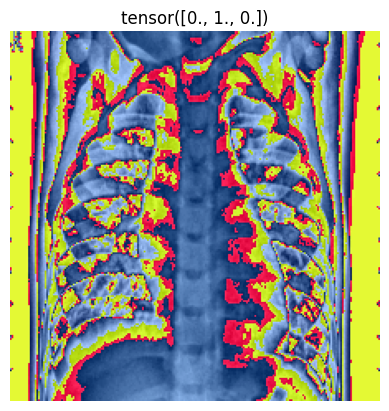

In [ ]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_loader))
plt.imshow(transforms.ToPILImage()(images[0]))
plt.title(labels[0])
plt.axis('off')
plt.show()


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

checkpoint_path = "/content/drive/MyDrive/ChestXray_Dataset/best_model.pth"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import timm
from torchvision import transforms
from tqdm import tqdm


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super(HybridAttention, self).__init__()

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid_channel = nn.Sigmoid()

        self.conv_spatial = nn.Conv1d(2, 1, kernel_size=7, padding=3)
        self.sigmoid_spatial = nn.Sigmoid()

    def forward(self, x):
        B, C = x.size()

        avg_out = self.fc(self.avg_pool(x.unsqueeze(-1)).squeeze(-1))
        max_out = self.fc(self.max_pool(x.unsqueeze(-1)).squeeze(-1))
        channel_attn = self.sigmoid_channel(avg_out + max_out)
        x = x * channel_attn

        x_ = x.unsqueeze(1)  # [B, 1, C]
        avg_out = torch.mean(x_, dim=1, keepdim=True)
        max_out, _ = torch.max(x_, dim=1, keepdim=True)
        spatial_attn = self.sigmoid_spatial(self.conv_spatial(torch.cat([avg_out, max_out], dim=1)))
        x = x * spatial_attn.squeeze(1)

        return x


In [ ]:
import torch
import torch.nn as nn
import timm

class AttentionEnhancedSwinHybrid(nn.Module):
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,
            global_pool=''
        )
        self.num_features = self.swin.num_features
        self.attention = HybridAttention(self.num_features)
        self.classifier = nn.Linear(self.num_features, num_classes)

    def forward(self, x):
        features = self.swin(x)
        if features.dim() == 4:
            features = features.mean(dim=(1,2))
        features = self.attention(features)
        out = self.classifier(features)
        return out


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AttentionEnhancedSwinHybrid(num_classes=3).to(device)

    dummy_input = torch.randn(4, 3, 224, 224).to(device)

    try:
        output = model(dummy_input)
        print("Success!")
        print(f"Input shape:  {dummy_input.shape}")
        print(f"Output shape: {output.shape}")  # Should be [4, 3]
    except RuntimeError as e:
        print(f"Runtime Error: {e}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Success!
Input shape:  torch.Size([4, 3, 224, 224])
Output shape: torch.Size([4, 3])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score  # Updated imports
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionEnhancedSwinHybrid(num_classes=3).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

checkpoint_path = "/content/drive/MyDrive/ChestXray_Dataset/best_model.pth"
best_val_loss = float('inf')

num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training")

    for images, labels in train_loader_tqdm:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.sigmoid(outputs).detach().cpu()
        all_preds.append(preds)
        all_labels.append(labels.cpu())

        current_loss = running_loss / (len(all_preds) * train_loader.batch_size)
        train_loader_tqdm.set_postfix(loss=current_loss)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_preds_binary = (all_preds >= 0.5).astype(int)

    train_acc = accuracy_score(all_labels, all_preds_binary)
    train_precision = precision_score(all_labels, all_preds_binary, average='macro', zero_division=0)
    train_recall = recall_score(all_labels, all_preds_binary, average='macro', zero_division=0)
    train_f1 = f1_score(all_labels, all_preds_binary, average='macro')


    model.eval()
    val_loss = 0.0
    val_preds_list = []
    val_labels_list = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.sigmoid(outputs).cpu()
            val_preds_list.append(preds)
            val_labels_list.append(labels.cpu())

    val_preds = torch.cat(val_preds_list).numpy()
    val_labels = torch.cat(val_labels_list).numpy()
    val_preds_binary = (val_preds >= 0.5).astype(int)

    val_acc = accuracy_score(val_labels, val_preds_binary)
    val_precision = precision_score(val_labels, val_preds_binary, average='macro', zero_division=0)
    val_recall = recall_score(val_labels, val_preds_binary, average='macro', zero_division=0)
    val_f1 = f1_score(val_labels, val_preds_binary, average='macro')

    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train | Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | Prec: {train_precision:.4f} | Rec: {train_recall:.4f} | F1: {train_f1:.4f}")
    print(f"Val   | Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_precision:.4f} | Rec: {val_recall:.4f} | F1: {val_f1:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), checkpoint_path)
        print(f"✅ Best model saved at epoch {epoch+1} with val loss: {best_val_loss:.4f}")

Epoch 1/10 - Training: 100%|██████████| 412/412 [02:13<00:00,  3.09it/s, loss=0.0059]



Epoch [1/10]
Train | Loss: 0.0944 | Acc: 0.9437 | Prec: 0.9534 | Rec: 0.9242 | F1: 0.9379
Val   | Loss: 0.0406 | Acc: 0.9788 | Prec: 0.9876 | Rec: 0.9685 | F1: 0.9776
✅ Best model saved at epoch 1 with val loss: 0.0406


Epoch 2/10 - Training: 100%|██████████| 412/412 [02:09<00:00,  3.18it/s, loss=0.00234]



Epoch [2/10]
Train | Loss: 0.0374 | Acc: 0.9806 | Prec: 0.9809 | Rec: 0.9797 | F1: 0.9803
Val   | Loss: 0.0423 | Acc: 0.9731 | Prec: 0.9832 | Rec: 0.9810 | F1: 0.9817


Epoch 3/10 - Training: 100%|██████████| 412/412 [02:08<00:00,  3.21it/s, loss=0.00141]


...


Epoch [8/10]
Train | Loss: 0.0118 | Acc: 0.9936 | Prec: 0.9908 | Rec: 0.9892 | F1: 0.9900
Val   | Loss: 0.0227 | Acc: 0.9873 | Prec: 0.9882 | Rec: 0.9908 | F1: 0.9895


Epoch 9/10 - Training: 100%|██████████| 412/412 [02:08<00:00,  3.20it/s, loss=0.000403]



Epoch [9/10]
Train | Loss: 0.0064 | Acc: 0.9968 | Prec: 0.9956 | Rec: 0.9972 | F1: 0.9964
Val   | Loss: 0.0263 | Acc: 0.9915 | Prec: 0.9945 | Rec: 0.9937 | F1: 0.9941


Epoch 10/10 - Training: 100%|██████████| 412/412 [02:12<00:00,  3.11it/s, loss=0.00089]



Epoch [10/10]
Train | Loss: 0.0142 | Acc: 0.9939 | Prec: 0.9932 | Rec: 0.9924 | F1: 0.9928
Val   | Loss: 0.0370 | Acc: 0.9788 | Prec: 0.9829 | Rec: 0.9850 | F1: 0.9839


In [ ]:
import torch

checkpoint_path = "/content/drive/MyDrive/ChestXray_Dataset/best_model.pth"

model = AttentionEnhancedSwinHybrid(num_classes=3)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model = model.to(device)

model.eval()

print("✅ Best model loaded successfully!")

✅ Best model loaded successfully!


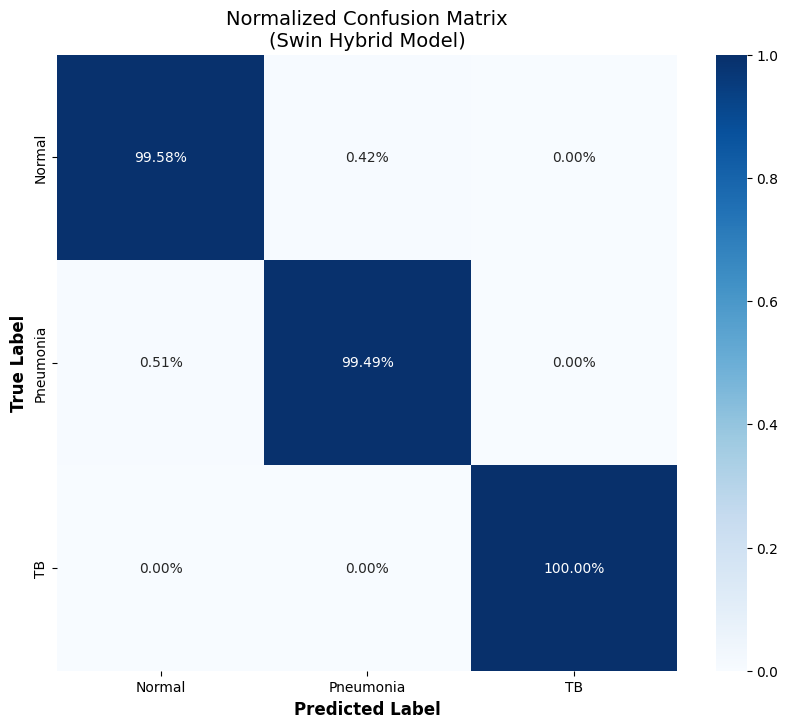


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       707
   Pneumonia       0.99      0.99      0.99       592
          TB       1.00      1.00      1.00       113

    accuracy                           1.00      1412
   macro avg       1.00      1.00      1.00      1412
weighted avg       1.00      1.00      1.00      1412



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    class_names = ['Normal', 'Pneumonia', 'TB']

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)

            if labels.dim() > 1:
                labels = torch.argmax(labels, dim=1)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_perc, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title('Normalized Confusion Matrix\n(Swin Hybrid Model)', fontsize=14)
    plt.show()

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

plot_confusion_matrix(model, val_loader, device)

In [ ]:
epochs = list(range(1, 11))

train_acc = [0.9437, 0.9806, 0.9873, 0.9892, 0.9910, 0.9968, 0.9900, 0.9936, 0.9968, 0.9939]
val_acc   = [0.9788, 0.9731, 0.9618, 0.9738, 0.9830, 0.9929, 0.9880, 0.9873, 0.9915, 0.9788]

train_prec = [0.9534, 0.9809, 0.9873, 0.9875, 0.9906, 0.9978, 0.9867, 0.9908, 0.9956, 0.9932]
val_prec   = [0.9876, 0.9832, 0.9777, 0.9805, 0.9884, 0.9950, 0.9883, 0.9882, 0.9945, 0.9829]

train_rec = [0.9242, 0.9797, 0.9879, 0.9861, 0.9892, 0.9978, 0.9833, 0.9892, 0.9972, 0.9924]
val_rec   = [0.9685, 0.9810, 0.9382, 0.9808, 0.9884, 0.9948, 0.9913, 0.9908, 0.9937, 0.9850]


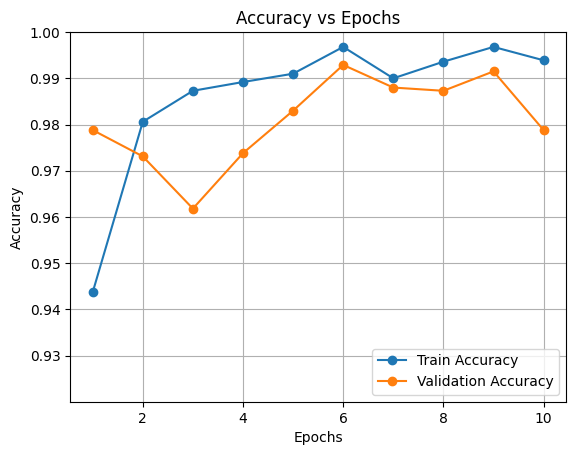

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')

plt.ylim(0.92, 1.00)
plt.yticks(np.arange(0.93, 1.001, 0.01))

plt.legend(loc='lower right')

plt.grid(True)

plt.show()

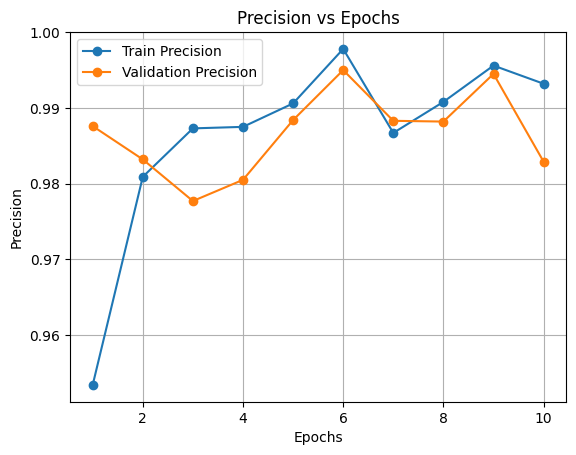

In [ ]:
plt.figure()
plt.plot(epochs, train_prec, marker='o', label='Train Precision')
plt.plot(epochs, val_prec, marker='o', label='Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Precision vs Epochs')
plt.legend()
plt.grid(True)
plt.show()


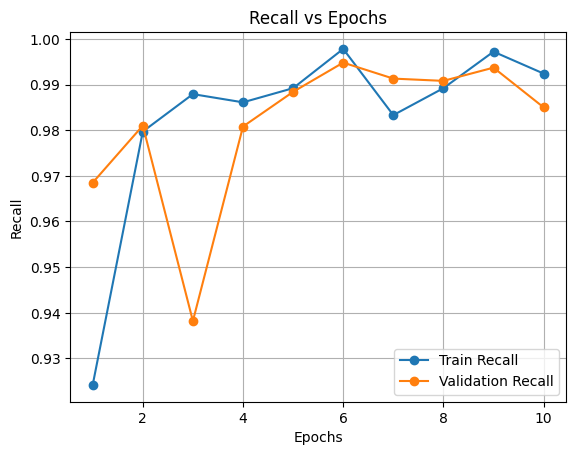

In [ ]:
plt.figure()
plt.plot(epochs, train_rec, marker='o', label='Train Recall')
plt.plot(epochs, val_rec, marker='o', label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Recall vs Epochs')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=b6800da6634e0101ddbcebd5defe779181ad8449e3b3a30b3df4eee441480de0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


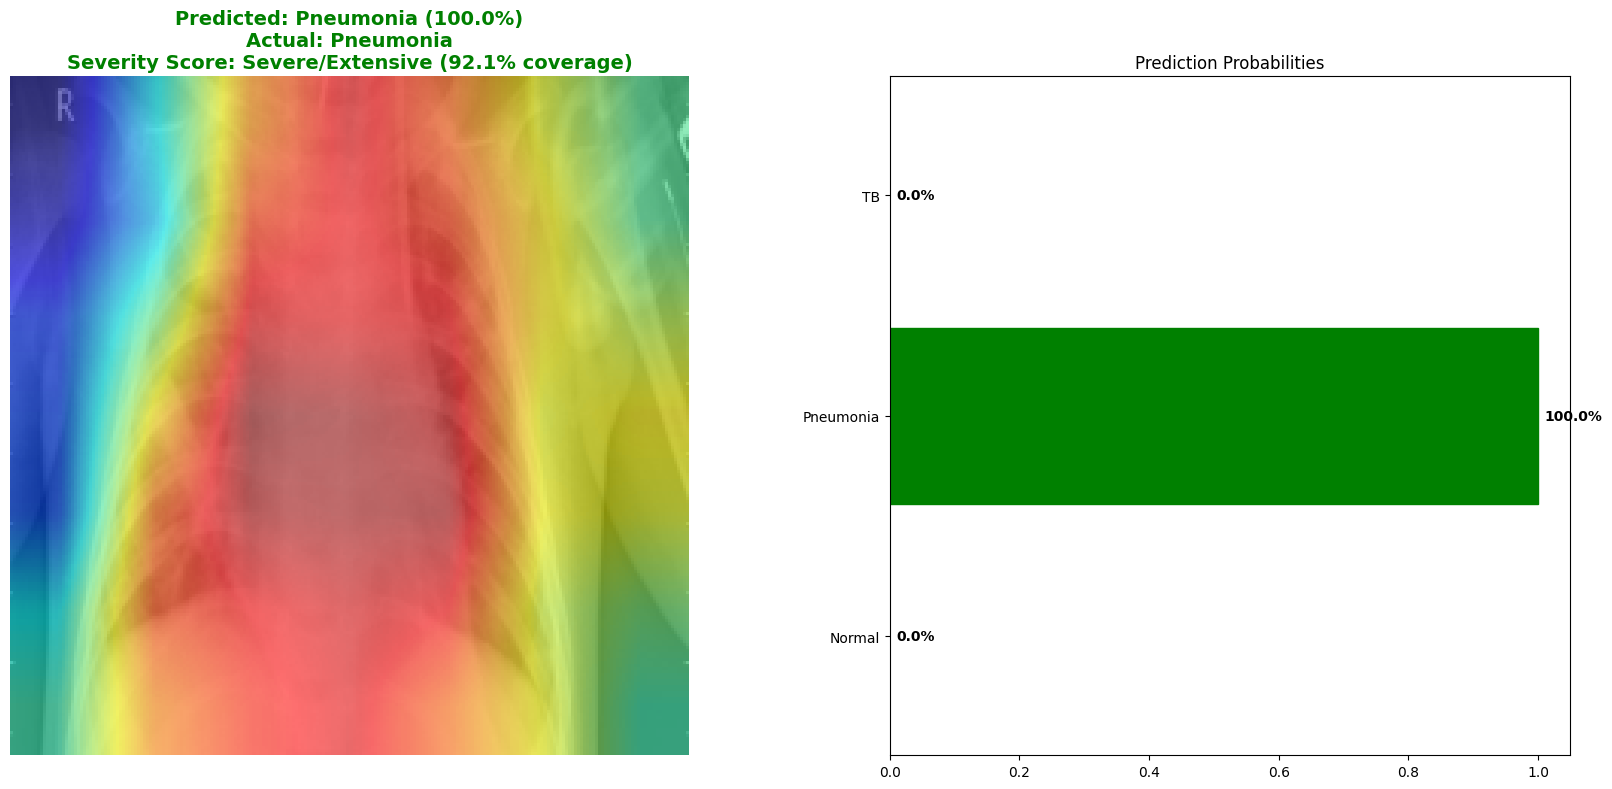

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image



def swin_reshape_transform(tensor, height=7, width=7):
    """Reshapes Swin Transformer output [B, H, W, C] to [B, C, H, W] for Grad-CAM."""
    if tensor.dim() == 4:
        result = tensor.permute(0, 3, 1, 2)
    elif tensor.dim() == 3:
        result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
        result = result.permute(0, 3, 1, 2)
    return result

def denormalize(img_tensor):
    """Converts ImageNet normalized tensor back to RGB [0, 1]."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * std) + mean
    return np.clip(img, 0, 1)



def get_lung_mask(img_tensor):
    """Creates a binary mask of the chest cavity using Otsu's thresholding."""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_uint8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask / 255.0

def calculate_severity(grayscale_cam, lung_mask, threshold=0.5):
    """Calculates disease extent ONLY within the lung mask area."""
    masked_cam = grayscale_cam * lung_mask
    binary_active = (masked_cam > threshold).astype(np.float32)

    total_lung_area = np.sum(lung_mask)
    if total_lung_area == 0: return 0, "N/A"

    severity_pct = (np.sum(binary_active) / total_lung_area) * 100

    if severity_pct < 5: label = "Mild"
    elif severity_pct < 20: label = "Moderate"
    else: label = "Severe/Extensive"

    return severity_pct, label



def run_final_medical_analysis(model, val_dataset, device):
    model.eval()
    class_names = ['Normal', 'Pneumonia', 'TB']

    idx = np.random.randint(len(val_dataset))
    img, label = val_dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    if isinstance(label, torch.Tensor):
        actual_idx = torch.argmax(label).item() if label.numel() > 1 else label.item()
    else:
        actual_idx = label

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0].cpu().numpy()
        pred_idx = np.argmax(probs)
        conf = probs[pred_idx]

    target_layers = [model.swin.layers[-1].blocks[-1].norm2]
    cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=swin_reshape_transform)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_idx)])[0, :]


    if class_names[pred_idx] in ['Pneumonia', 'TB']:
        lung_mask = get_lung_mask(img)
        sev_score, sev_label = calculate_severity(grayscale_cam, lung_mask)
    else:
        sev_score, sev_label = 0.0, "None (Healthy)"

    img_rgb = denormalize(img)
    cam_image = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.5, 1]})

    ax1.imshow(cam_image)
    status_color = 'green' if pred_idx == actual_idx else 'red'
    ax1.set_title(f"Predicted: {class_names[pred_idx]} ({conf:.1%})\n"
                  f"Actual: {class_names[actual_idx]}\n"
                  f"Severity Score: {sev_label} ({sev_score:.1f}% coverage)",
                  color=status_color, fontsize=14, fontweight='bold')
    ax1.axis('off')

    y_pos = np.arange(len(class_names))
    bars = ax2.barh(y_pos, probs, color='lightgray')
    bars[pred_idx].set_color(status_color)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(class_names)
    ax2.set_xlim(0, 1.05)
    ax2.set_title("Prediction Probabilities")

    for i, v in enumerate(probs):
        ax2.text(v + 0.01, i, f"{v:.1%}", va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
run_final_medical_analysis(model, val_dataset, device)

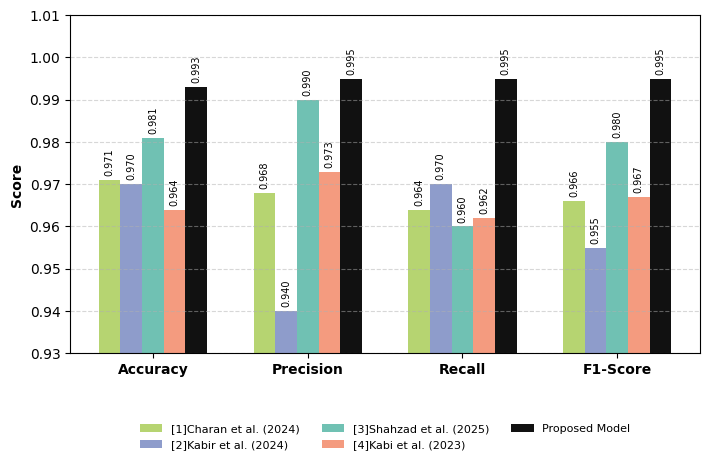

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

ieee_2024 = [0.971, 0.968, 0.964, 0.966]
heliyon_2024 = [0.970, 0.940, 0.970, 0.955]
mra_2025 = [0.981, 0.990, 0.960, 0.980]
ieee_2023 = [0.964, 0.973, 0.962, 0.967]
proposed = [0.993, 0.995, 0.995, 0.995]

x = np.arange(len(categories))
width = 0.14

fig, ax = plt.subplots(figsize=(7.2, 4.8))

colors = ['#B6D471', '#8E9CCB', '#70C1B3', '#F49B7F', '#111111']

rects1 = ax.bar(x - 2*width, ieee_2024, width, label='[1]Charan et al. (2024)', color=colors[0])
rects2 = ax.bar(x - width, heliyon_2024, width, label='[2]Kabir et al. (2024)', color=colors[1])
rects3 = ax.bar(x, mra_2025, width, label='[3]Shahzad et al. (2025)', color=colors[2])
rects4 = ax.bar(x + width, ieee_2023, width, label='[4]Kabi et al. (2023)', color=colors[3])
rects5 = ax.bar(x + 2*width, proposed, width, label='Proposed Model', color=colors[4])

ax.set_ylabel('Score', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax.set_ylim(0.93, 1.01)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    rotation=90, fontsize=7)

for r in [rects1, rects2, rects3, rects4, rects5]:
    autolabel(r)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=3, frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig('tb_comparison_updated_authors.png', dpi=600, bbox_inches='tight')
plt.show()